#  Old Photo Restoration
## Digital Image Processing Pipeline

---

### What this notebook does
Old photographs suffer from several types of damage over time:
- **Noise and grain** — random pixel variations caused by the analog film process or physical degradation
- **Scratches and cracks** — thin bright lines caused by physical damage to the photo surface
- **Low contrast** — fading caused by aging of the photographic paper
- **Sepia / color cast** — yellowing of the paper over decades

### Pipeline overview
```
Original Image
     │
     ▼
Step 1 — Denoising          (remove grain and noise)
     │
     ▼
Step 2 — Scratch Detection  (find damaged areas → binary mask)
     │
     ▼
Step 3 — Inpainting         (fill in the damaged areas)
     │
     ▼
Step 4 — Contrast (CLAHE)   (improve local contrast)
     │
     ▼
Step 5 — Color Correction   (fix sepia / grayscale tone)
     │
     ▼
Final Restored Image
```

---
## 1. Imports and Helper Functions

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def show_images(images, titles, cmap_list=None, figsize=None):
    """
    Display a row of images side by side.
    """
    n = len(images)
    if figsize is None:
        figsize = (5 * n, 5)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        cmap = None
        if cmap_list and cmap_list[titles.index(title)]:
            cmap = cmap_list[titles.index(title)]
            ax.imshow(img, cmap=cmap)
        elif len(img.shape) == 2:          # already grayscale
            ax.imshow(img, cmap='gray')
        else:                              # BGR → RGB
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=13)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

---
## 2. Load Images


Loaded C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img1.jpg — size: 592×784 pixels

Total images loaded: 1


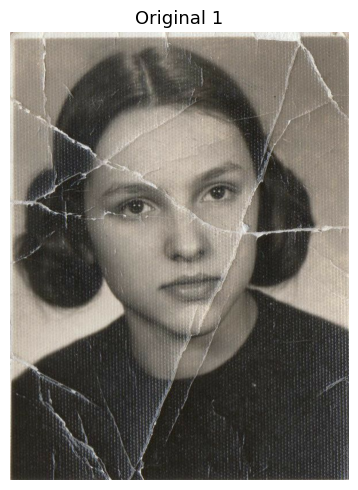

In [25]:
# ── Configuration: add or remove paths here ──────────────────────────────────
IMAGE_PATHS = [
    r"C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img1.jpg",
    # r"C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img2.jpg",
    # r"C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img3.jpg",
    # r"C:\Users\Zakaria\Downloads\digital_project\old-photo-restoration-dip\assets\gallery_originals\img4.jpg",
]

# Load all images
originals = []
for path in IMAGE_PATHS:
    img = cv2.imread(path)
    if img is None:
        print(f"WARNING: Could not load {path}")
    else:
        originals.append(img)
        print(f"Loaded {path} — size: {img.shape[1]}×{img.shape[0]} pixels")

print(f"\nTotal images loaded: {len(originals)}")

# Display all originals
show_images(
    originals,
    [f"Original {i+1}" for i in range(len(originals))]
)

---
## Step 1 — Denoising

Old photos contain **noise** — random variations in pixel brightness that were introduced by:
- The grain structure of analog film
- Physical deterioration of the paper surface
- Dust and dirt on the scanner

Noise must be removed **first**, before scratch detection, because noise can be mistakenly detected as scratches in the next step.

### Methods compared

| Method | How it works | Speed | Quality |
|--------|-------------|-------|--------|
| **Median Filter** | Replaces each pixel with the median value of its neighbors | Fast | Good for salt-and-pepper noise |
| **Non-Local Means (NLM)** | Finds similar patches across the whole image and averages them | Slow | Better — preserves edges and texture |

### Parameters to tune

**Median Filter:**
- `kernel_size` — size of the neighborhood. Must be an odd number.
  - Small (3): mild smoothing, keeps detail
  - Medium (5): balanced — good default
  - Large (7, 9): aggressive smoothing, may blur fine detail

**Non-Local Means:**
- `h` — filter strength. Controls how much noise is removed.
  - Low (5): mild, keeps more detail but less noise removed
  - Medium (10): good default
  - High (15-20): aggressive, may blur texture
- `templateWindowSize` — size of the patch to compare (default 7, always odd)
- `searchWindowSize` — how far to search for similar patches (default 21, always odd). Larger = better quality but much slower.

── Image 1 ──


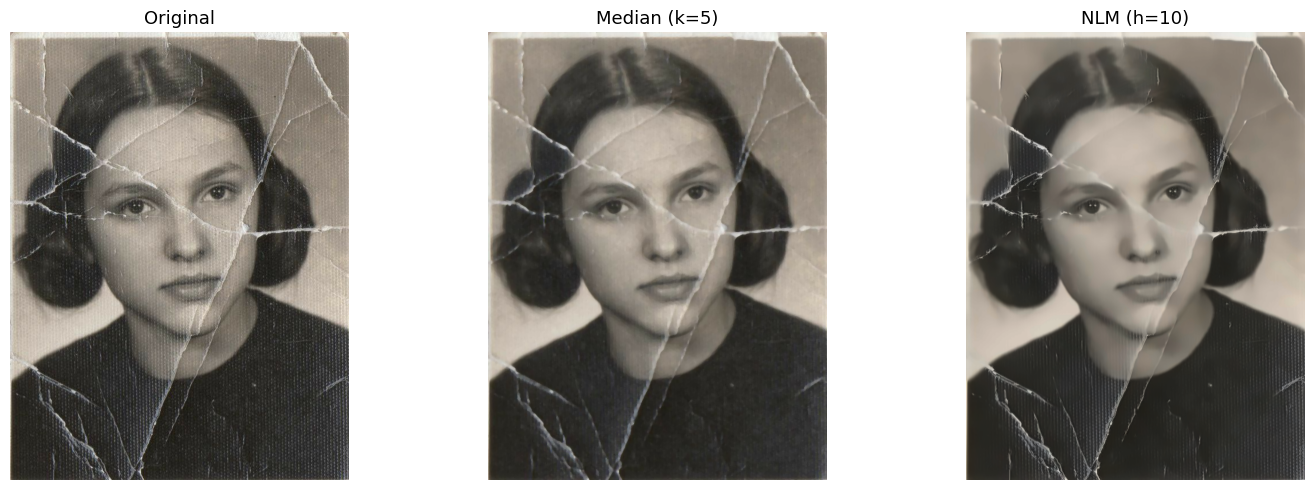

Denoising complete. Using NLM output for next step.


In [26]:
# ── Parameters — tune 
MEDIAN_KERNEL  = 5     # must be odd: 3, 5, 7
NLM_H          = 10    # filter strength: 5 (mild) → 15 (strong)
NLM_TEMPLATE   = 7     # patch size (keep at 7)
NLM_SEARCH     = 21    # search window (keep at 21)

# Apply denoising to all images
denoised_all = []

for i, img in enumerate(originals):
    median = cv2.medianBlur(img, MEDIAN_KERNEL)
    nlm    = cv2.fastNlMeansDenoisingColored(img, None, NLM_H, NLM_H,
                                             NLM_TEMPLATE, NLM_SEARCH)
    denoised_all.append(nlm)   # NLM is the chosen method

    # Show comparison for each image
    print(f"── Image {i+1} ──")
    show_images(
        [img, median, nlm],
        ["Original", f"Median (k={MEDIAN_KERNEL})", f"NLM (h={NLM_H})"]
    )

print("Denoising complete. Using NLM output for next step.")

### Parameter tuning guide for denoising

Run the cell below to quickly compare three values of `h` on one image and pick the best.

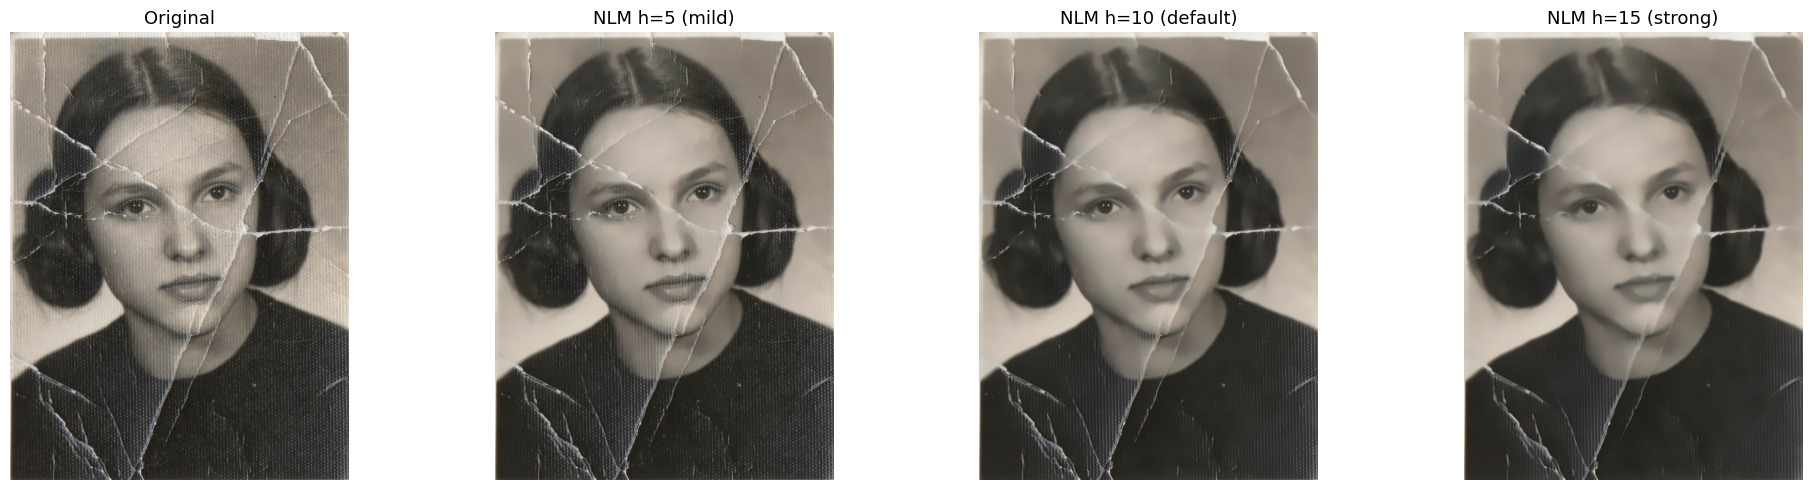

In [ ]:
# Tuning cell: compare NLM at h = 5, 10, 15 on image 1
img_test = originals[0]

nlm_5  = cv2.fastNlMeansDenoisingColored(img_test, None,  5,  5, 7, 21)
nlm_10 = cv2.fastNlMeansDenoisingColored(img_test, None, 10, 10, 7, 21)
nlm_15 = cv2.fastNlMeansDenoisingColored(img_test, None, 15, 15, 7, 21)

show_images(
    [img_test, nlm_5, nlm_10, nlm_15],
    ["Original", "NLM h=5 (mild)", "NLM h=10 (default)", "NLM h=15 (strong)"]
)
# Observation: h=5 keeps more texture, h=15 is smoother but may lose fine detail.

---
## Step 2 — Scratch Detection

Scratches and cracks appear as **thin, bright lines** over the photo. We cannot simply erase them — we need to first **find exactly where they are** so that the repair step (inpainting) knows which pixels to reconstruct.

The output of this step is a **binary mask**: a black-and-white image where:
- **White (255)** = scratch pixel that needs to be repaired
- **Black (0)** = clean pixel that should not be touched

### Method: Morphological Top-Hat Transform

The **top-hat transform** highlights features that are **brighter than their surroundings** and **smaller than the structuring element**. Scratches are exactly that — bright thin lines.

How it works:
1. Apply a **morphological opening** (erosion followed by dilation) — this removes small bright features
2. Subtract the opened image from the original — what remains is the small bright features (the scratches)

We run the transform **twice** — once with a horizontal kernel (to find horizontal scratches) and once with a vertical kernel (to find vertical scratches). Then we combine both.

### Parameters to tune

- `kernel_length` — length of the structuring element (the bar used to detect lines)
  - Too short (< 15): detects noise as scratches
  - Good range (20–35): detects real scratches reliably
  - Too long (> 50): misses short scratches

- `threshold` — minimum brightness to count as a scratch
  - Too low (< 20): marks non-scratch areas as damaged
  - Good range (25–40): marks actual scratches only
  - Too high (> 50): misses faint scratches

- `dilation_iterations` — how much to expand the mask after thresholding
  - 0: exact scratch width, may leave edges unrepaired
  - 1–2: slight expansion, ensures the inpainter covers the full scratch
  - 3+: too aggressive, may cover good pixels

Image 1: 12928 scratch pixels (2.8%) | adaptive threshold used: 40


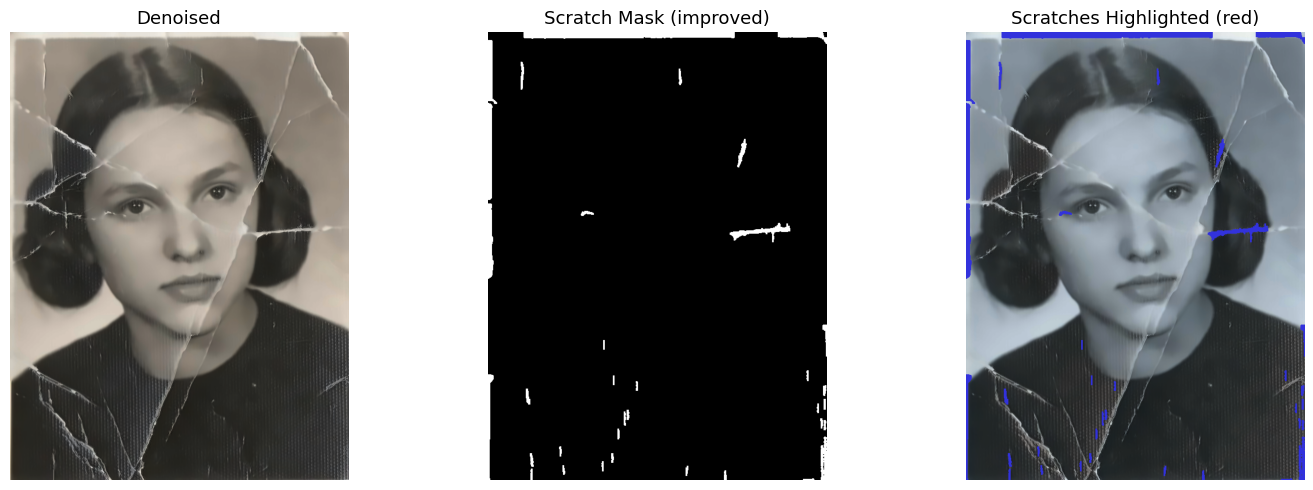

Scratch detection complete.


In [ ]:
# Parameters — tune these
KERNEL_LENGTH     = 25   # length of line detector: 15–35 recommended
BRIGHT_CUTOFF     = 40   # ignore pixels darker than this (vignette / dark clothing)
ADAPTIVE_FACTOR   = 0.55 # fraction of 97th percentile used as threshold (0.4–0.7)
MIN_SCRATCH_LEN   = 15   # minimum length of a valid scratch component (pixels)
MIN_ASPECT_RATIO  = 3    # minimum aspect ratio (length/width) to count as a scratch
DILATION_ITER     = 1    # mask expansion: 0, 1, or 2


#  Apply scratch detection to all images
masks_all = []

for i, img in enumerate(denoised_all):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # brightness mask — exclude dark regions from detection
    _, bright_mask = cv2.threshold(gray, BRIGHT_CUTOFF, 255, cv2.THRESH_BINARY)

    # Top-hat transform
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (KERNEL_LENGTH, 1))
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, KERNEL_LENGTH))
    tophat_h = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, h_kernel)
    tophat_v = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, v_kernel)
    combined = cv2.bitwise_or(tophat_h, tophat_v)

    #adaptive threshold from image statistics
    p97             = np.percentile(combined, 97)
    adaptive_thresh = max(40, int(p97 * ADAPTIVE_FACTOR))
    _, mask         = cv2.threshold(combined, adaptive_thresh, 255, cv2.THRESH_BINARY)

    # Apply brightness mask — remove detections in dark areas
    mask = cv2.bitwise_and(mask, bright_mask)

    # shape filter — keep only elongated connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    filtered = np.zeros_like(mask)
    for lbl in range(1, num_labels):
        w       = stats[lbl, cv2.CC_STAT_WIDTH]
        h       = stats[lbl, cv2.CC_STAT_HEIGHT]
        max_dim = max(w, h)
        min_dim = max(min(w, h), 1)
        if max_dim >= MIN_SCRATCH_LEN and (max_dim / min_dim) >= MIN_ASPECT_RATIO:
            filtered[labels == lbl] = 255
    mask = filtered

    # Dilate slightly
    if DILATION_ITER > 0:
        mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=DILATION_ITER)

    masks_all.append(mask)

    # Overlay in red for inspection
    overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    overlay[mask == 255] = [220, 50, 50]

    scratch_pixels = cv2.countNonZero(mask)
    total_pixels   = mask.shape[0] * mask.shape[1]
    print(f"Image {i+1}: {scratch_pixels} scratch pixels ({100*scratch_pixels/total_pixels:.1f}%) | adaptive threshold used: {adaptive_thresh}")

    show_images(
        [img, mask, overlay],
        ["Denoised", "Scratch Mask (improved)", "Scratches Highlighted (red)"],
        cmap_list=[None, 'gray', None]
    )

print("Scratch detection complete.")

### Parameter tuning guide for scratch detection

The cell below shows the effect of different threshold values on the mask. A good mask should mark the white crack lines and nothing else.

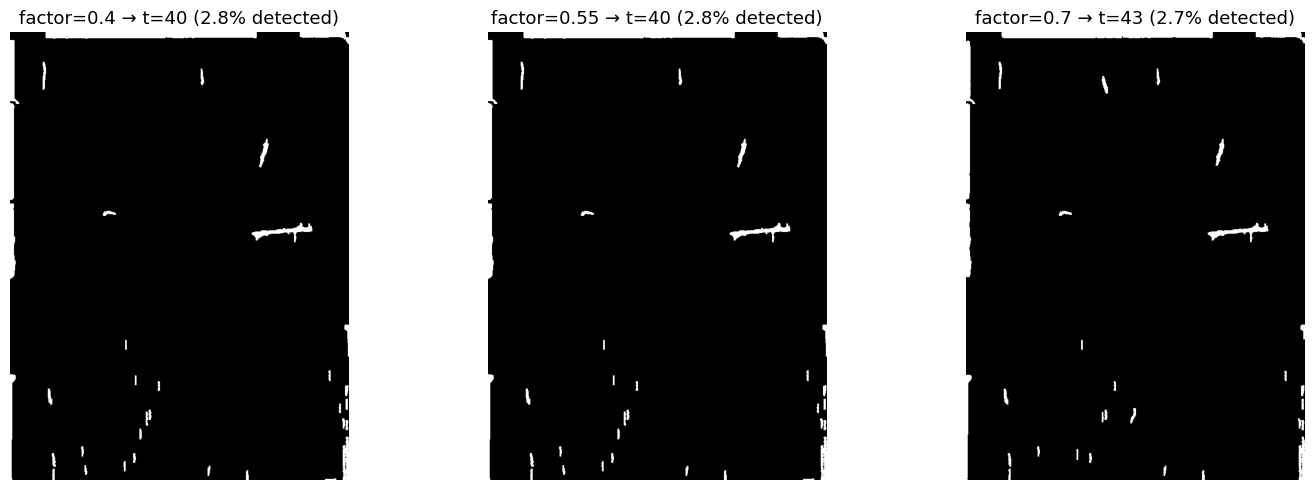

In [ ]:
# Tuning cell: compare ADAPTIVE_FACTOR = 0.4, 0.55, 0.7 on image 1 
# The adaptive factor controls how high above background the response must be.
# Lower factor = more sensitive (detects fainter scratches but more false positives)
# Higher factor = less sensitive (cleaner but may miss faint damage)

img_test = denoised_all[0]
gray     = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)
_, bm    = cv2.threshold(gray, 40, 255, cv2.THRESH_BINARY)
h_k = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
v_k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
combined = cv2.bitwise_or(cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, h_k),
                          cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, v_k))
p97 = np.percentile(combined, 97)

masks_tuning = []
labels_tuning = []
for factor in [0.4, 0.55, 0.7]:
    t = max(40, int(p97 * factor))
    _, m = cv2.threshold(combined, t, 255, cv2.THRESH_BINARY)
    m = cv2.bitwise_and(m, bm)
    # shape filter
    nl, lb, st, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    f = np.zeros_like(m)
    for lbl in range(1, nl):
        w=st[lbl,cv2.CC_STAT_WIDTH]; h=st[lbl,cv2.CC_STAT_HEIGHT]
        mx=max(w,h); mn=max(min(w,h),1)
        if mx>=15 and mx/mn>=3: f[lb==lbl]=255
    f = cv2.dilate(f, np.ones((3,3),np.uint8), iterations=1)
    masks_tuning.append(f)
    pct = 100*cv2.countNonZero(f)/(gray.shape[0]*gray.shape[1])
    labels_tuning.append(f"factor={factor} → t={t} ({pct:.1f}% detected)")

show_images(masks_tuning, labels_tuning, cmap_list=['gray','gray','gray'])
# Observation: factor=0.4 is more sensitive, factor=0.7 is conservative.
# factor=0.55 is the balanced default for these photos.

---
## Step 3 — Inpainting

Now that we know **where** the scratches are (the mask from Step 2), we need to **fill in** those damaged pixels with plausible values. This is called **inpainting**.

The algorithm looks at the pixels surrounding each masked region and propagates texture and color into the damaged area. It does **not** use any machine learning — it is a purely mathematical operation.

### Methods compared

| Method | How it works | Best for |
|--------|-------------|----------|
| **TELEA** | Fast Marching Method — propagates pixel values from the boundary inward | Thin scratches and cracks |
| **Navier-Stokes (NS)** | Based on fluid dynamics equations — smoothly continues edges and structure | Wider or more complex damage |

### Parameters to tune

- `inpaint_radius` — how far around each masked pixel the algorithm looks for reference pixels
  - Small (2–3): faster, good for thin scratches
  - Large (5–8): better for wide damage but slower and may over-smooth

── Image 1 ──


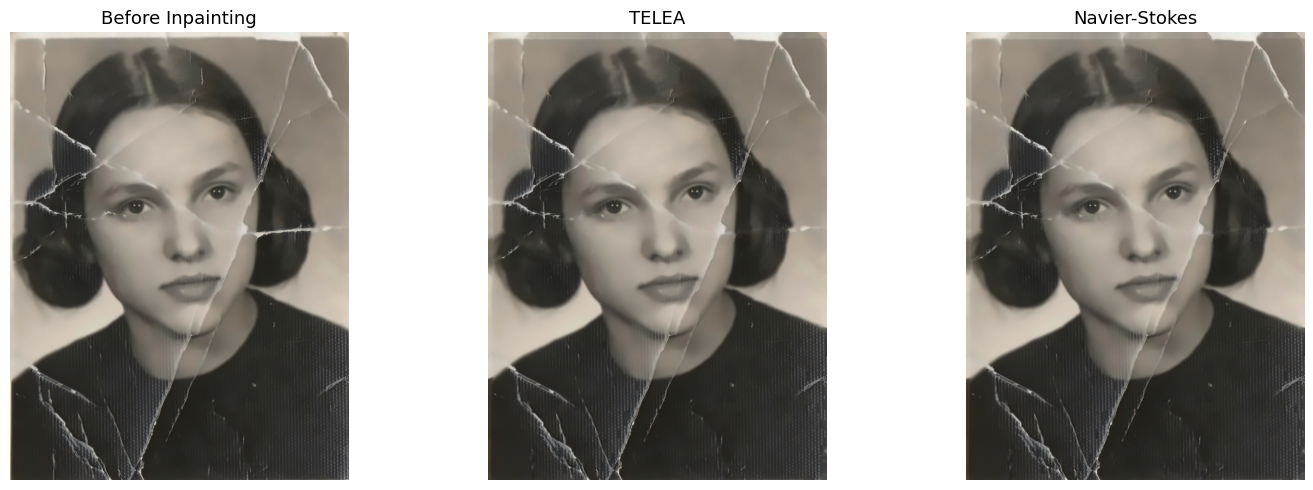

Inpainting complete. Using TELEA output for next step.


In [39]:
# Parameters — tune these
INPAINT_RADIUS = 3    # neighborhood radius: 2–8

#  Apply inpainting to all images 
inpainted_all = []

for i, (img, mask) in enumerate(zip(denoised_all, masks_all)):

    inpainted_telea = cv2.inpaint(img, mask, INPAINT_RADIUS, cv2.INPAINT_TELEA)
    inpainted_ns    = cv2.inpaint(img, mask, INPAINT_RADIUS, cv2.INPAINT_NS)

    inpainted_all.append(inpainted_telea)   # TELEA is the chosen method

    print(f"── Image {i+1} ──")
    show_images(
        [img, inpainted_telea, inpainted_ns],
        ["Before Inpainting", "TELEA", "Navier-Stokes"]
    )

print("Inpainting complete. Using TELEA output for next step.")

### Parameter tuning guide for inpainting

Compare radius values on one image to see the effect on scratch fill quality.

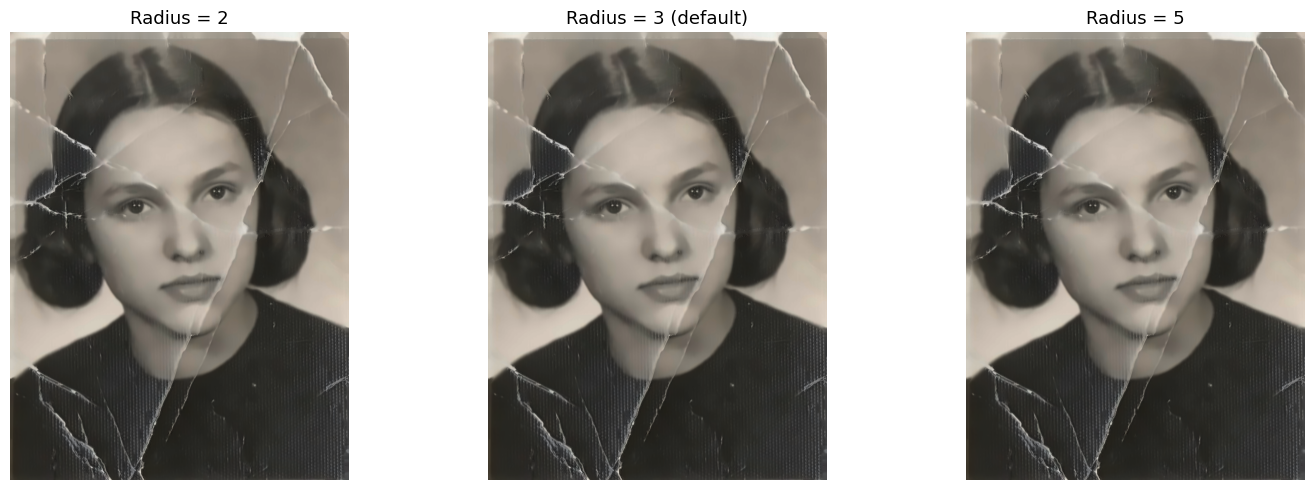

In [40]:
#  Tuning cell: compare inpaint_radius = 2, 3, 5 on image 1 
img_test  = denoised_all[0]
mask_test = masks_all[0]

r2 = cv2.inpaint(img_test, mask_test, 2, cv2.INPAINT_TELEA)
r3 = cv2.inpaint(img_test, mask_test, 3, cv2.INPAINT_TELEA)
r5 = cv2.inpaint(img_test, mask_test, 5, cv2.INPAINT_TELEA)

show_images(
    [r2, r3, r5],
    ["Radius = 2", "Radius = 3 (default)", "Radius = 5"]
)
# Observation: radius=2 may leave faint trace of scratch.
# radius=5 is smoother but blurs fine detail around the scratch.

---
## Step 4 — Contrast Enhancement (CLAHE)

Old photos often have **low contrast** — the entire image looks washed out or flat because:
- The paper has faded uniformly
- The tonal range has compressed over time

A simple global contrast adjustment (like regular histogram equalization) would over-brighten some areas and crush others. Instead, we use **CLAHE** — Contrast Limited Adaptive Histogram Equalization.

### How CLAHE works
1. Divides the image into small tiles (e.g., 8×8)
2. Applies histogram equalization **independently** to each tile
3. Clips the histogram at a limit to prevent over-amplifying noise
4. Blends the tiles smoothly together

Because we work **locally**, dark regions of the photo can be brightened without blowing out already-bright regions.

### Why we work in LAB color space
If we applied CLAHE directly to the BGR channels, we would change the color balance of the photo. Instead we:
1. Convert to **LAB** color space (L = lightness, A and B = color channels)
2. Apply CLAHE only to the **L channel** (brightness)
3. Leave the A and B channels unchanged (colors stay the same)
4. Convert back to BGR

### Parameters to tune

- `clip_limit` — maximum allowed histogram height per tile. Controls how aggressive the enhancement is.
  - Low (1.0): mild enhancement, natural look
  - Medium (2.0–3.0): good default range
  - High (4.0+): strong enhancement, may look over-processed or noisy

- `tile_size` — size of each local tile in pixels
  - Small (4×4, 8×8): very local enhancement, good for fine detail
  - Large (16×16): smoother, more global effect

── Image 1 ──


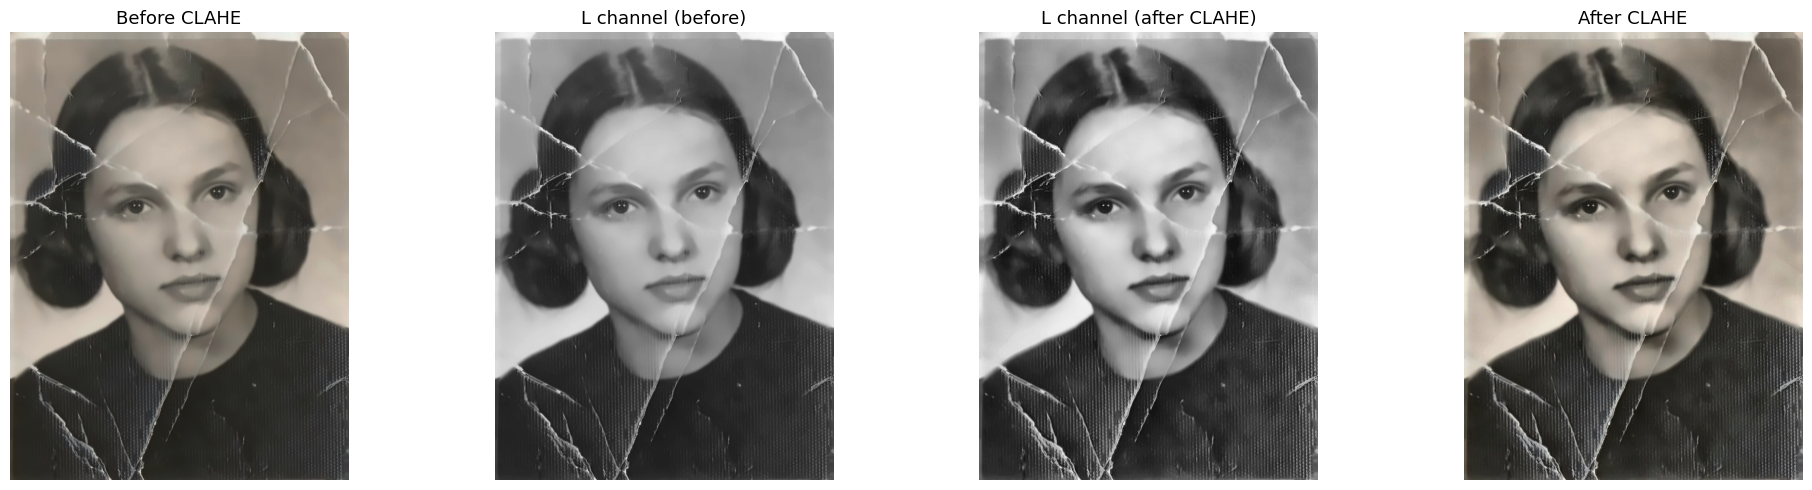

Contrast enhancement complete.


In [41]:
#  Parameters — tune these
CLAHE_CLIP  = 2.0      # contrast limit: 1.0 (mild) → 4.0 (strong)
CLAHE_TILE  = (8, 8)   # tile size: (4,4), (8,8), or (16,16)

# Apply CLAHE to all images 
enhanced_all = []
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

for i, img in enumerate(inpainted_all):

    # Convert to LAB — work only on the L (lightness) channel
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to lightness only
    l_clahe = clahe.apply(l)

    # Merge back and convert to BGR
    enhanced = cv2.cvtColor(cv2.merge((l_clahe, a, b)), cv2.COLOR_LAB2BGR)
    enhanced_all.append(enhanced)

    print(f"── Image {i+1} ──")
    show_images(
        [img, l, l_clahe, enhanced],
        ["Before CLAHE", "L channel (before)", "L channel (after CLAHE)", "After CLAHE"],
        cmap_list=[None, 'gray', 'gray', None]
    )

print("Contrast enhancement complete.")

### Parameter tuning guide for CLAHE

Compare three clip limit values to see how aggressive the enhancement becomes.

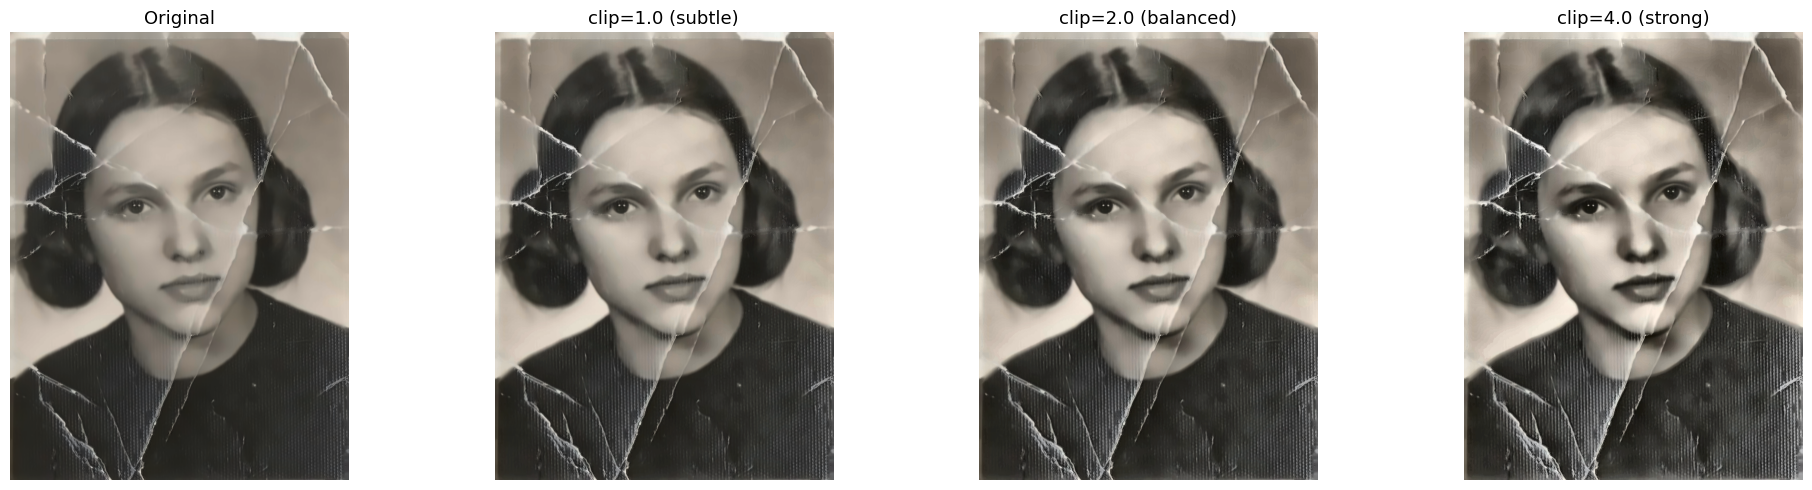

In [33]:
# ── Tuning cell: compare clip_limit = 1.0, 2.0, 4.0 on image 1 ───────────────
img_test = inpainted_all[0]
lab      = cv2.cvtColor(img_test, cv2.COLOR_BGR2LAB)
l, a, b  = cv2.split(lab)

results = []
for clip in [1.0, 2.0, 4.0]:
    l_c = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8)).apply(l)
    results.append(cv2.cvtColor(cv2.merge((l_c, a, b)), cv2.COLOR_LAB2BGR))

show_images(
    [img_test] + results,
    ["Original", "clip=1.0 (subtle)", "clip=2.0 (balanced)", "clip=4.0 (strong)"]
)
# Observation: clip=1.0 is too gentle, clip=4.0 can look unnatural.
# clip=2.0 is the best balance for these photos.

---
## Step 5 — Color Correction

### Why?
Many old photos have a **color cast** caused by aging:
- **Sepia**: the paper has yellowed, giving a warm brown-orange tone
- **Grayscale**: purely black-and-white photos may look muddy or flat
- **Color**: some older photos retain their original colors and need no correction

We first **classify** the image to decide which correction to apply, then apply the appropriate fix.

### Classification: how to detect image type
We use the **HSV color space** (Hue, Saturation, Value):
- **Hue** (0–180 in OpenCV): which color family dominates
- **Saturation** (0–255): how pure/vivid the colors are

| Type | Mean Saturation | Mean Hue |
|------|----------------|----------|
| Grayscale | < 15 | any |
| Sepia | 15 – 60 | 10 – 30 (yellow-orange) |
| Color | > 60 | any |

### Sepia removal: White Balance Correction
Each color channel (Blue, Green, Red) has a different mean brightness in a sepia image. We scale each channel so that all three means become equal — this **neutralizes the yellow cast**.

### Grayscale cleanup: Unsharp Mask + Histogram Stretch
For black-and-white photos:
1. **Unsharp mask** — sharpens edges by subtracting a blurred version of the image
2. **Histogram stretch** — remaps the pixel values to use the full 0–255 range

Image 1: detected as 'sepia' (mean_hue=21.8, mean_sat=29.5)


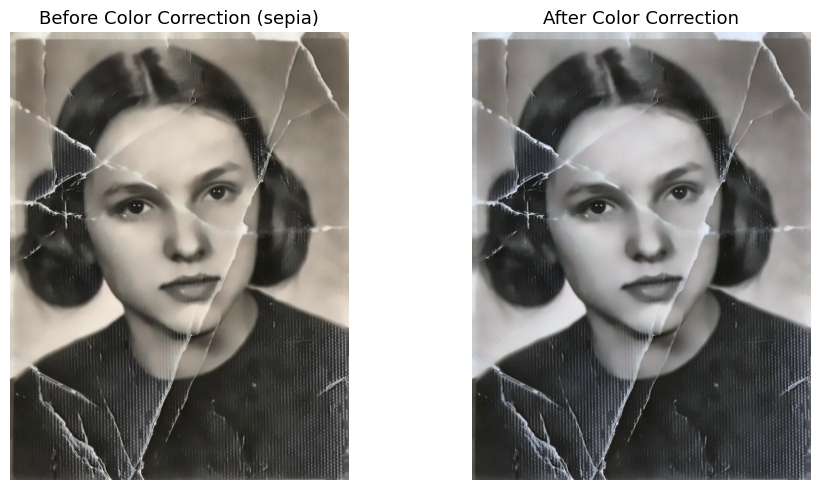

Color correction complete.


In [42]:
# Parameters — tune these
SEPIA_SAT_MIN  = 15    # minimum saturation to distinguish from grayscale
SEPIA_SAT_MAX  = 60    # maximum saturation for sepia (above = real color)
SEPIA_HUE_MIN  = 10    # minimum hue for sepia yellow-orange range
SEPIA_HUE_MAX  = 30    # maximum hue for sepia yellow-orange range

#  Color correction functions 

def classify_image(img):
    """Return 'grayscale', 'sepia', or 'color'."""
    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_sat = hsv[:, :, 1].mean()
    mean_hue = hsv[:, :, 0].mean()
    if mean_sat < SEPIA_SAT_MIN:
        return 'grayscale'
    elif SEPIA_HUE_MIN <= mean_hue <= SEPIA_HUE_MAX and mean_sat < SEPIA_SAT_MAX:
        return 'sepia'
    return 'color'

def remove_sepia(img):
    """White-balance correction: equalize mean brightness across all 3 channels."""
    result      = img.astype(np.float32)
    global_mean = result.mean()
    for ch in range(3):                          # B, G, R
        ch_mean = result[:, :, ch].mean()
        if ch_mean > 0:
            result[:, :, ch] *= (global_mean / ch_mean)
    return np.clip(result, 0, 255).astype(np.uint8)

def clean_grayscale(img):
    """Unsharp mask + histogram stretch for black-and-white photos."""
    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred   = cv2.GaussianBlur(gray, (0, 0), 3)
    sharpened = cv2.addWeighted(gray, 1.5, blurred, -0.5, 0)   # unsharp mask
    stretched = cv2.normalize(sharpened, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.cvtColor(stretched, cv2.COLOR_GRAY2BGR)

def correct_color(img):
    """Classify and apply the right correction automatically."""
    kind = classify_image(img)
    if kind == 'sepia':
        return remove_sepia(img), kind
    elif kind == 'grayscale':
        return clean_grayscale(img), kind
    return img.copy(), kind

#  Apply to all images 
final_all = []

for i, img in enumerate(enhanced_all):
    result, kind = correct_color(img)
    final_all.append(result)

    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mean_sat = hsv[:, :, 1].mean()
    mean_hue = hsv[:, :, 0].mean()
    print(f"Image {i+1}: detected as '{kind}' (mean_hue={mean_hue:.1f}, mean_sat={mean_sat:.1f})")

    show_images(
        [img, result],
        [f"Before Color Correction ({kind})", "After Color Correction"]
    )

print("Color correction complete.")

---
## Step 6 — Final Comparison

Show the **original** and the **fully restored** image side by side for every photo in the dataset.

── Image 1 ──


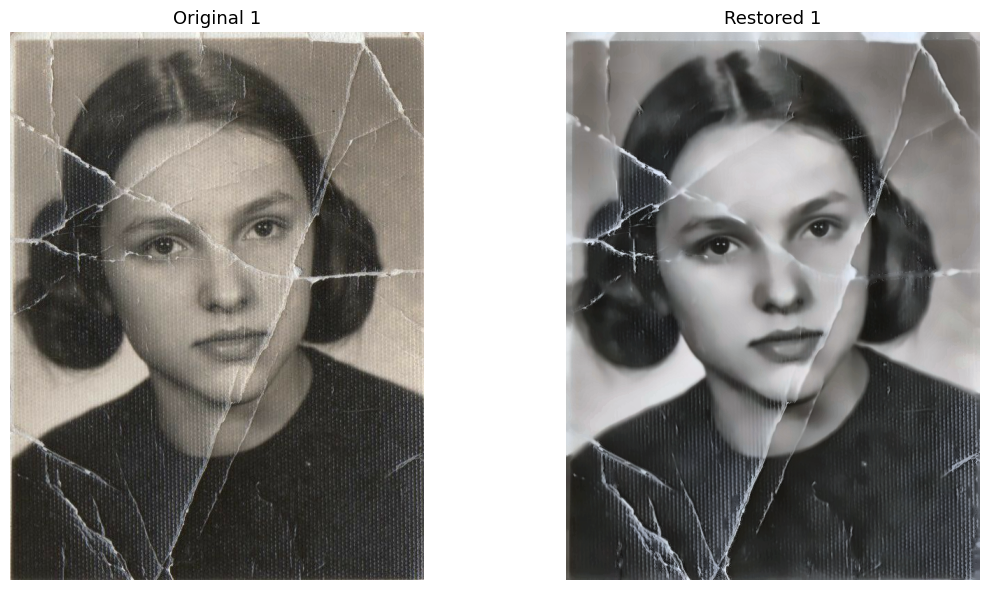

In [ ]:
#  Side-by-side before / after for every image 
for i, (orig, final) in enumerate(zip(originals, final_all)):
    print(f"── Image {i+1} ──")
    show_images(
        [orig, final],
        [f"Original {i+1}", f"Restored {i+1}"],
        figsize=(12, 6)
    )

---
## Step 7 — All Steps in One View

Show the progression through every pipeline step for each image in a single figure.

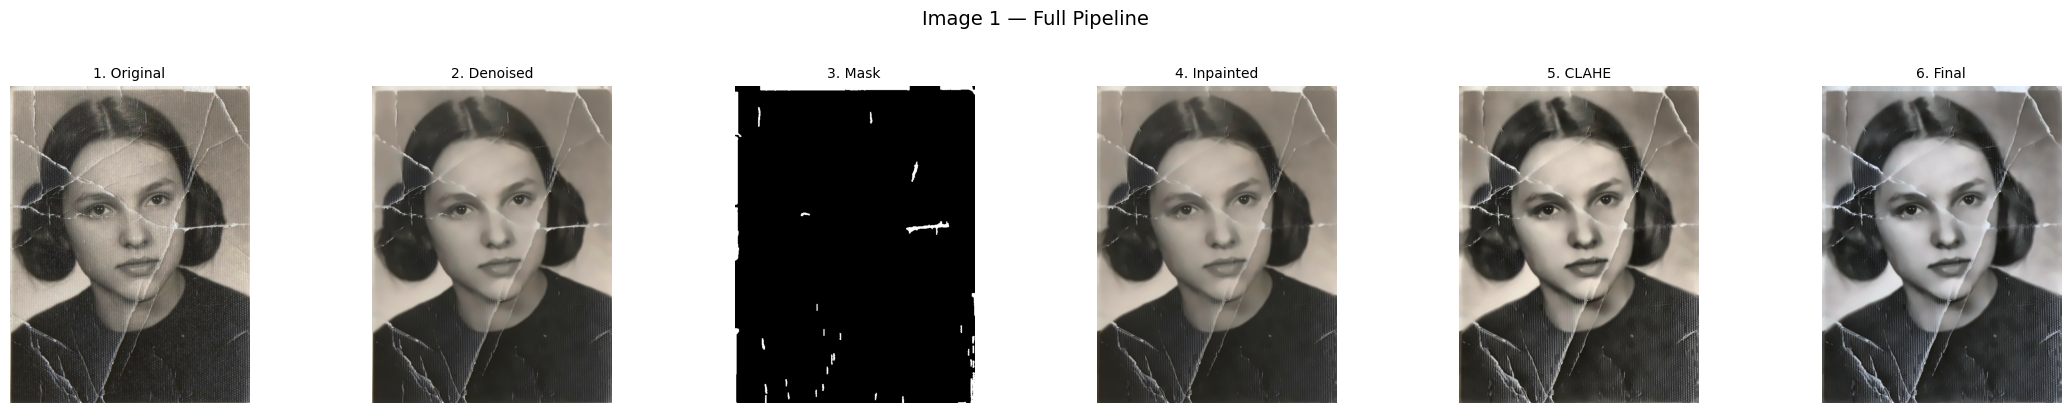

In [44]:
#  Full pipeline progression for every image
step_labels = [
    "1. Original",
    "2. Denoised",
    "3. Mask",
    "4. Inpainted",
    "5. CLAHE",
    "6. Final"
]

for i in range(len(originals)):
    steps = [
        originals[i],
        denoised_all[i],
        masks_all[i],
        inpainted_all[i],
        enhanced_all[i],
        final_all[i]
    ]
    cmaps = [None, None, 'gray', None, None, None]

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    fig.suptitle(f"Image {i+1} — Full Pipeline", fontsize=14, y=1.02)

    for ax, step_img, label, cmap in zip(axes, steps, step_labels, cmaps):
        if cmap:
            ax.imshow(step_img, cmap=cmap)
        elif len(step_img.shape) == 2:
            ax.imshow(step_img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(step_img, cv2.COLOR_BGR2RGB))
        ax.set_title(label, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

---
## Step 8 — Agreed Parameters Table

After reviewing the results across all images, record the final agreed parameter values here. These values will be used by **Member 3** when converting this notebook into modules.

| Step | Parameter | Value | Notes |
|------|-----------|-------|-------|
| Denoising | Method | NLM | Better quality than Median |
| Denoising | h (NLM strength) | 10 | |
| Denoising | templateWindowSize | 7 | |
| Denoising | searchWindowSize | 21 | |
| Denoising | Median kernel | 5 | Used as fast fallback |
| Scratch Detection | kernel_length | 25 | Both H and V kernels |
| Scratch Detection | threshold | 30 | |
| Scratch Detection | dilation_iterations | 1 | |
| Inpainting | Method | TELEA | |
| Inpainting | inpaint_radius | 3 | |
| CLAHE | clip_limit | 2.0 | |
| CLAHE | tile_size | (8, 8) | |
| Color | grayscale threshold (sat) | 15 | |
| Color | sepia sat range | 15–60 | |
| Color | sepia hue range | 10–30 | |

> **Team note:** If any member finds better parameters during their module work, update this table and inform the team before changing `main.py`.

In [48]:
# Save final results to disk 
import os
os.makedirs("output", exist_ok=True)

for i, (orig, final) in enumerate(zip(originals, final_all)):
    out_path = f"output/restored_{i+1}.jpg"
    cv2.imwrite(out_path, final)
    print(f"Saved: {out_path}")

print("\nAll restored images saved to output/ folder.")

Saved: output/restored_1.jpg

All restored images saved to output/ folder.
